# WallOmics workshop: AI multi-omics integration

This participant notebook uses the real, preprocessed WallOmics rosette data to demonstrate PCA, sample-similarity graphs, GCNs, and MOGONET-style VCDN fusion. It predicts the real experimental temperature factor (15°C versus 22°C); it does not create synthetic data or labels.

## Workshop Setup — Load Frozen WallOmics Data

1. Clone or download this workshop GitHub repository.
2. This notebook uses **preprocessed, frozen WallOmics data**. Participants do **not** need to download or process the raw dataset.
3. Put the frozen files in `data/processed/`, relative to the repository root.

Two ways to obtain the frozen data:

- **Option A — GitHub:** download the files directly from `data/processed/` in the workshop repository.
- **Option B — Google Drive:** download the frozen-data ZIP from `<GOOGLE_DRIVE_DATA_LINK>` and extract its contents into `data/processed/`.

The MOGONET demonstration requires exactly these frozen files: `rna_processed.csv`, `proteomics_processed.csv`, `metabolomics_processed.csv`, and `sample_metadata.csv`.

### Workshop flow

Load frozen WallOmics data → inspect modalities → RNA/proteomics/metabolomics → PCA representations → sample-similarity graphs → GCN → VCDN fusion → temperature prediction → baseline comparison → modality ablation → take-home message.


### Import the analysis tools

This cell loads the standard numerical tools used throughout the workshop and fixes random seeds for a reproducible demonstration. Expect version messages confirming that the core tools are ready.

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Set reproducible random seeds
np.random.seed(42)
import random
random.seed(42)

print("[OK] Imports successful")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


[OK] Imports successful
NumPy version: 2.5.2
Pandas version: 3.0.5


### Load the frozen WallOmics inputs

This reads the four already processed files with paths relative to the repository root. It matters because these frozen inputs replace every raw-data download and preprocessing step. Expect a confirmation of the input directory; if a required file is missing, the error names it.

In [2]:
from pathlib import Path

DATA_DIR = Path("data") / "processed"
REQUIRED_FILES = {
    "RNA": "rna_processed.csv",
    "Proteomics": "proteomics_processed.csv",
    "Metabolomics": "metabolomics_processed.csv",
    "Metadata": "sample_metadata.csv",
}
missing = [name for name, filename in REQUIRED_FILES.items() if not (DATA_DIR / filename).is_file()]
if missing:
    raise FileNotFoundError(
        "Missing frozen WallOmics file(s): " + ", ".join(missing) +
        f". Place the four required CSV files in {DATA_DIR.as_posix()}/."
    )

rna = pd.read_csv(DATA_DIR / REQUIRED_FILES["RNA"], index_col=0)
prot = pd.read_csv(DATA_DIR / REQUIRED_FILES["Proteomics"], index_col=0)
met = pd.read_csv(DATA_DIR / REQUIRED_FILES["Metabolomics"], index_col=0)
metadata = pd.read_csv(DATA_DIR / REQUIRED_FILES["Metadata"], index_col=0)

print(f"[OK] Loaded frozen WallOmics data from: {DATA_DIR.as_posix()}/")


[OK] Loaded frozen WallOmics data from: data/processed/


### Verify the workshop inputs

This is a quick readiness check, not a preprocessing step. It confirms the number of matched samples, feature counts, metadata availability, and the real target used later. Expect 30 matched samples and a `Temperature` target with 15°C and 22°C labels.

In [3]:
sample_order = list(rna.index)
if not (sample_order == list(prot.index) == list(met.index) == list(metadata.index)):
    raise ValueError(
        "Frozen files must contain the same matched sample IDs in the same order. "
        "Re-download and extract the complete data/processed/ folder."
    )
if "Temperature" not in metadata.columns:
    raise ValueError("sample_metadata.csv must include the real 'Temperature' column.")

print(f"Matched samples: {len(sample_order)}")
print(f"RNA features: {rna.shape[1]}")
print(f"Proteomics features: {prot.shape[1]}")
print(f"Metabolomics features: {met.shape[1]}")
print(f"Metadata available: {', '.join(metadata.columns)}")
print("MOGONET prediction target: Temperature (real experimental labels: 15°C vs 22°C)")
print("Temperature labels:")
print(metadata["Temperature"].value_counts().sort_index())


Matched samples: 30
RNA features: 19763
Proteomics features: 364
Metabolomics features: 6
Metadata available: Temperature, Ecotype, Organ
MOGONET prediction target: Temperature (real experimental labels: 15°C vs 22°C)
Temperature labels:
Temperature
15    15
22    15
Name: count, dtype: int64


## Inspect modalities

The three matrices are already standardized and feature-filtered; this cell only summarizes their dimensions. This matters because each omics layer has a different measurement scale and feature count. Expect one row each for RNA, proteomics, metabolomics, and metadata.

In [4]:
modality_summary = pd.DataFrame(
    {
        "samples": [rna.shape[0], prot.shape[0], met.shape[0], metadata.shape[0]],
        "features_or_columns": [rna.shape[1], prot.shape[1], met.shape[1], metadata.shape[1]],
    },
    index=["RNA", "Proteomics", "Metabolomics", "Metadata"],
)
display(modality_summary)


,samples,features_or_columns
RNA,30,19763
Proteomics,30,364
Metabolomics,30,6
Metadata,30,3


### Prepare PCA and visualization tools

This loads PCA and plotting support, and checks whether UMAP is available (with a t-SNE fallback). It matters because the next section creates compact representations and visual summaries. Expect a message naming the available 2D-embedding method.

In [5]:
# ============================================================================
# Imports and dependency check
# ============================================================================
import sys
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def _ensure(pip_name, import_name=None):
    import_name = import_name or pip_name
    try:
        __import__(import_name)
        return True
    except ImportError:
        print(f"[WARN] {pip_name} not found. Installing...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
            __import__(import_name)
            print(f"[OK] {pip_name} installed")
            return True
        except Exception as e:
            print(f"[WARN] Could not install {pip_name}: {e}")
            return False

_ensure("matplotlib")

# UMAP is optional and its 'numba' dependency can trigger OS-level DLL/JIT policy
# blocks on some machines. We probe UMAP importability in an isolated subprocess
# first, so a blocked DLL never touches this kernel process; only import it here
# if the probe succeeds. Otherwise we transparently fall back to sklearn's t-SNE.
UMAP_AVAILABLE = False
probe = subprocess.run(
    [sys.executable, "-c", "import umap"],
    capture_output=True, text=True
)
if probe.returncode == 0:
    import umap
    UMAP_AVAILABLE = True
    print("[OK] UMAP available - will use UMAP for 2D embeddings")
else:
    reason = probe.stderr.strip().splitlines()[-1] if probe.stderr.strip() else "import failed"
    print(f"[WARN] UMAP unavailable ({reason})")
    print("  Falling back to sklearn TSNE for 2D embeddings")

from sklearn.manifold import TSNE  # always import - cheap, and used as fallback

print("[OK] Ready for baseline integration analysis")


[OK] UMAP available - will use UMAP for 2D embeddings
[OK] Ready for baseline integration analysis


## What the modalities measure

- **RNA (transcriptomics):** gene-expression measurements, indicating which genes are actively transcribed.
- **Proteomics:** protein-abundance measurements, closer to the molecular machinery carrying out cellular functions.
- **Metabolomics:** small-molecule measurements, reflecting biochemical state and pathway activity.

MOGONET keeps these views separate at first, so each can form its own sample-similarity graph before learned fusion combines them.


## PCA representations

### Build a compact representation for each modality

PCA summarizes each high-dimensional frozen matrix into its dominant axes of variation. This makes the representations easier to visualize and supplies compact features for the early-fusion baseline. Expect the retained component count and variance explained for each modality.

In [6]:
# ============================================================================
# STEP 3: Apply PCA separately to each modality
# ============================================================================
n_samples = rna.shape[0]

# Number of PCA components is capped by both a target range (10-20) and by
# what's mathematically possible (n_components <= min(n_samples, n_features)).
N_COMPONENTS_TARGET = 20
max_components = max(2, min(N_COMPONENTS_TARGET, n_samples - 1))

def run_pca(df, name, n_components):
    n_comp = min(n_components, df.shape[1], df.shape[0] - 1)
    pca = PCA(n_components=n_comp, random_state=42)
    scores = pca.fit_transform(df.values)
    scores_df = pd.DataFrame(
        scores,
        index=df.index,
        columns=[f"{name}_PC{i+1}" for i in range(n_comp)]
    )
    var_explained = pca.explained_variance_ratio_.sum()
    print(f"{name:12s}: {df.shape[1]:4d} features -> {n_comp:2d} PCs "
          f"({var_explained*100:5.1f}% variance explained)")
    return scores_df, pca

print(f"Target components: up to {max_components} (min(n_samples-1, {N_COMPONENTS_TARGET}))\n")

rna_pca, rna_pca_model = run_pca(rna, "RNA", max_components)
prot_pca, prot_pca_model = run_pca(prot, "Proteomics", max_components)
met_pca, met_pca_model = run_pca(met, "Metabolomics", max_components)


Target components: up to 20 (min(n_samples-1, 20))

RNA         : 19763 features -> 20 PCs ( 94.5% variance explained)
Proteomics  :  364 features -> 20 PCs ( 89.1% variance explained)
Metabolomics:    6 features ->  6 PCs (100.0% variance explained)


### Combine the modality-specific PCA scores

This is the simple early-fusion representation: the three PCA score tables are concatenated. It provides a classical point of comparison for graph-based MOGONET fusion. Expect the dimensions of each PCA table and the combined table.

In [7]:
# ============================================================================
# STEP 4: Early fusion - concatenate PCA representations
# ============================================================================
# RNA_PCA + Proteomics_PCA + Metabolomics_PCA -> integrated matrix
fused_pca = pd.concat([rna_pca, prot_pca, met_pca], axis=1)

print("Early-fusion (concatenated) representation:")
print(f"  RNA PCA:           {rna_pca.shape}")
print(f"  Proteomics PCA:    {prot_pca.shape}")
print(f"  Metabolomics PCA:  {met_pca.shape}")
print(f"  ---------------------------------")
print(f"  Fused matrix:      {fused_pca.shape}")

assert fused_pca.shape[1] == rna_pca.shape[1] + prot_pca.shape[1] + met_pca.shape[1]
assert list(fused_pca.index) == list(rna.index)
print("[OK] Fused representation is sample-aligned with the original matrices")


Early-fusion (concatenated) representation:
  RNA PCA:           (30, 20)
  Proteomics PCA:    (30, 20)
  Metabolomics PCA:  (30, 6)
  ---------------------------------
  Fused matrix:      (30, 46)
[OK] Fused representation is sample-aligned with the original matrices


### Choose the real experimental labels for visualization

The workshop colors visualizations with the real temperature metadata, the same experimental factor used for MOGONET prediction. Expect the counts for 15°C and 22°C samples.

In [8]:
color_col = "Temperature"
color_values = metadata[color_col]
print(f"[OK] Coloring representations by real metadata column: '{color_col}'")
print(color_values.value_counts().sort_index())


[OK] Coloring representations by real metadata column: 'Temperature'
Temperature
15    15
22    15
Name: count, dtype: int64


### Make 2D PCA visualizations

This reduces each PCA representation to two dimensions using UMAP when available, or t-SNE otherwise. It helps participants see broad sample patterns; it is descriptive, not a prediction result. Expect a method message and a two-dimensional result for each modality and their early fusion.

In [9]:
# ============================================================================
# STEP 6: 2D embedding of each PCA representation (UMAP, or t-SNE fallback)
# ============================================================================
def embed_2d(matrix, n_samples, random_state=42):
    n_neighbors = max(2, min(15, n_samples - 1))
    if UMAP_AVAILABLE:
        reducer = umap.UMAP(n_neighbors=n_neighbors, n_components=2, random_state=random_state)
        return reducer.fit_transform(matrix), "UMAP"
    else:
        perplexity = max(2, min(30, n_samples - 1))
        reducer = TSNE(n_components=2, perplexity=perplexity, random_state=random_state, init="pca")
        return reducer.fit_transform(matrix), "t-SNE"

representations = {
    "RNA": rna_pca,
    "Proteomics": prot_pca,
    "Metabolomics": met_pca,
    "Fused (early integration)": fused_pca,
}

embeddings = {}
method_name = None
for name, mat in representations.items():
    emb, method_name = embed_2d(mat.values, n_samples)
    embeddings[name] = emb
    print(f"{name:28s}: {mat.shape} -> 2D {method_name} embedding {emb.shape}")


RNA                         : (30, 20) -> 2D UMAP embedding (30, 2)
Proteomics                  : (30, 20) -> 2D UMAP embedding (30, 2)
Metabolomics                : (30, 6) -> 2D UMAP embedding (30, 2)
Fused (early integration)   : (30, 46) -> 2D UMAP embedding (30, 2)


### View the PCA representations

This plot displays the RNA, proteomics, metabolomics, and early-fusion views side by side, colored by temperature. Expect four panels; the figure remains in the notebook and does not overwrite the frozen input files.

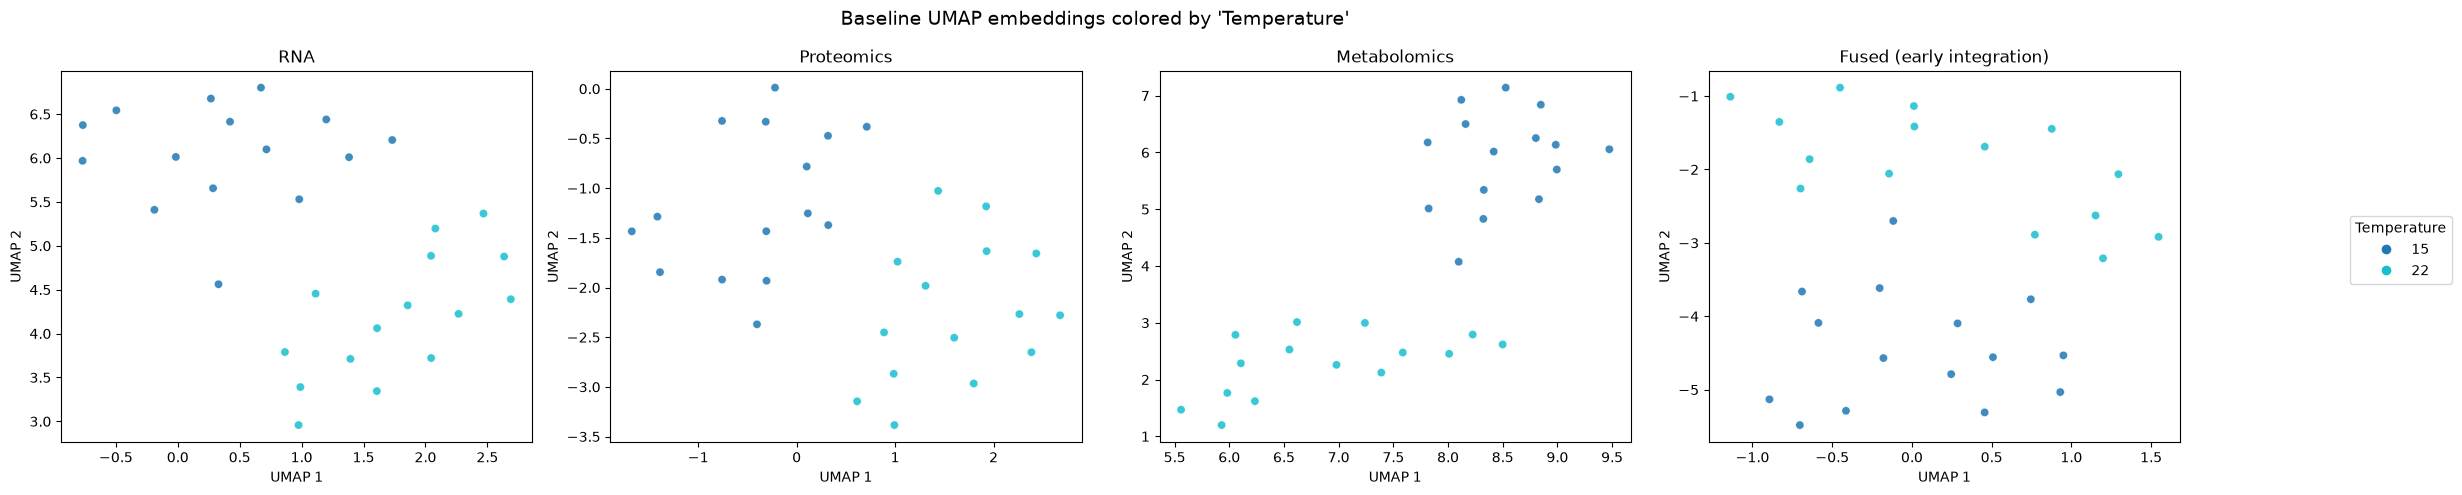

In [10]:
# ============================================================================
# STEP 7: Side-by-side visualization of all embeddings
# ============================================================================
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

is_categorical = not pd.api.types.is_numeric_dtype(color_values) or color_values.nunique() <= 10
if is_categorical:
    categories = pd.Categorical(color_values)
    codes = categories.codes
    cmap = plt.get_cmap("tab10")
else:
    codes = color_values.values
    cmap = plt.get_cmap("viridis")

for ax, (name, emb) in zip(axes, embeddings.items()):
    scatter = ax.scatter(emb[:, 0], emb[:, 1], c=codes, cmap=cmap, s=35, alpha=0.85, edgecolors="white", linewidths=0.3)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel(f"{method_name} 1")
    ax.set_ylabel(f"{method_name} 2")

if is_categorical:
    handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=cmap(i / max(1, len(categories.categories) - 1)),
                          markersize=8, label=str(cat)) for i, cat in enumerate(categories.categories)]
    fig.legend(handles=handles, title=color_col, loc="center right", bbox_to_anchor=(1.12, 0.5))
else:
    fig.colorbar(scatter, ax=axes, shrink=0.7, label=color_col)

fig.suptitle(f"Baseline {method_name} embeddings colored by '{color_col}'", fontsize=14)
plt.tight_layout()
plt.show()



### Summarize the representations

This prints the original and PCA-reduced dimensions. It makes the dimensionality reduction concrete before moving to graphs and neural networks. Expect a compact dimension table.

In [11]:
# ============================================================================
# STEP 8: Summary of all representation dimensions
# ============================================================================
print("="*70)
print("Baseline Multi-Omics Integration: Dimension Summary")
print("="*70)
print(f"\n{'Representation':<28s}{'Samples':>10s}{'Features':>12s}")
print("-"*50)
print(f"{'RNA (processed)':<28s}{rna.shape[0]:>10d}{rna.shape[1]:>12d}")
print(f"{'Proteomics (processed)':<28s}{prot.shape[0]:>10d}{prot.shape[1]:>12d}")
print(f"{'Metabolomics (processed)':<28s}{met.shape[0]:>10d}{met.shape[1]:>12d}")
print("-"*50)
print(f"{'RNA PCA':<28s}{rna_pca.shape[0]:>10d}{rna_pca.shape[1]:>12d}")
print(f"{'Proteomics PCA':<28s}{prot_pca.shape[0]:>10d}{prot_pca.shape[1]:>12d}")
print(f"{'Metabolomics PCA':<28s}{met_pca.shape[0]:>10d}{met_pca.shape[1]:>12d}")
print(f"{'Fused (early integration)':<28s}{fused_pca.shape[0]:>10d}{fused_pca.shape[1]:>12d}")
print("-"*50)
print(f"2D embedding method used: {method_name}")
print("\n[OK] Baseline PCA + early-fusion integration complete")


Baseline Multi-Omics Integration: Dimension Summary

Representation                 Samples    Features
--------------------------------------------------
RNA (processed)                     30       19763
Proteomics (processed)              30         364
Metabolomics (processed)            30           6
--------------------------------------------------
RNA PCA                             30          20
Proteomics PCA                      30          20
Metabolomics PCA                    30           6
Fused (early integration)           30          46
--------------------------------------------------
2D embedding method used: UMAP

[OK] Baseline PCA + early-fusion integration complete


---

## Sample-similarity graphs, GCNs, and VCDN fusion

MOGONET-style integration first represents each modality as a graph of similar samples, learns with a GCN in each view, and then fuses the view-specific predictions with VCDN. The leakage-free split happens before PCA and graph construction.

> With only 30 real samples, the reported scores illustrate the complete architecture and are not a rigorous biological-performance benchmark.


### Import MOGONET demonstration tools

This loads PyTorch and the machine-learning tools used for graphs, classification, and evaluation. The cell may install a CPU-only PyTorch build if needed. Expect a readiness message before the model steps.

In [12]:
# ============================================================================
# Imports and dependency check
# ============================================================================
import sys
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

def _ensure_torch():
    try:
        import torch  # noqa: F401
        return True
    except ImportError:
        print("[WARN] torch not found. Installing CPU-only build...")
        try:
            subprocess.check_call([
                sys.executable, "-m", "pip", "install", "-q",
                "torch", "--index-url", "https://download.pytorch.org/whl/cpu"
            ])
            print("[OK] torch installed")
            return True
        except Exception as e:
            print(f"[ERROR] Could not install torch: {e}")
            return False

if not _ensure_torch():
    raise RuntimeError("PyTorch is required for the MOGONET section but could not be installed.")

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("[OK] Ready for MOGONET-style graph integration")
print(
    "[NOTE] Using a minimal pure-PyTorch GCN (adjacency-matrix message passing) "
    "instead of PyTorch Geometric, to avoid extra native-dependency installs on CPU-only machines."
)


[OK] Ready for MOGONET-style graph integration
[NOTE] Using a minimal pure-PyTorch GCN (adjacency-matrix message passing) instead of PyTorch Geometric, to avoid extra native-dependency installs on CPU-only machines.


### Attach the real temperature prediction target

This converts the real WallOmics temperature labels into the two classes used by the model: 15°C and 22°C. It matters because no label is inferred from molecular measurements. Expect the observed class counts.

In [13]:
n_samples = rna.shape[0]
temperature = metadata["Temperature"]
y = temperature.map({15: 0, 22: 1}).values  # 0 = 15°C, 1 = 22°C
if pd.isna(y).any():
    raise ValueError("Temperature labels must be the real WallOmics 15°C/22°C values.")
class_names = ["15°C", "22°C"]
print(f"[OK] {n_samples} frozen samples available for MOGONET")
print(f"\nTemperature label distribution:\n{temperature.value_counts().sort_index()}")


[OK] 30 frozen samples available for MOGONET

Temperature label distribution:
Temperature
15    15
22    15
Name: count, dtype: int64


### Split data before representation learning

This makes a stratified training/test split before fitting PCA or building graphs. That ordering is essential to keep held-out test data from influencing learned representations. Expect train/test sample counts and class counts.

In [14]:
# ============================================================================
# STEP 2: Stratified train/test split - performed BEFORE any PCA, scaling, or
# graph construction, so no test sample can influence how those are fitted.
# ============================================================================
idx_all = np.arange(n_samples)
train_idx, test_idx = train_test_split(
    idx_all, test_size=0.3, random_state=SEED,
    stratify=y if len(np.unique(y)) > 1 and min(np.bincount(y)) >= 2 else None
)
print(f"Train: {len(train_idx)} samples | Test: {len(test_idx)} samples")
print(f"Train label counts: {np.bincount(y[train_idx])} | Test label counts: {np.bincount(y[test_idx])}")

train_mask = torch.zeros(n_samples, dtype=torch.bool); train_mask[train_idx] = True
test_mask = torch.zeros(n_samples, dtype=torch.bool); test_mask[test_idx] = True
y_t = torch.tensor(y, dtype=torch.long)


Train: 21 samples | Test: 9 samples
Train label counts: [10 11] | Test label counts: [5 4]


### Fit PCA using training samples only

Each modality receives a separate PCA fit using only the training rows; the fitted transform is then applied to held-out samples. This preserves the notebook's leakage-free evaluation protocol. Expect train-only variance explained for all three modalities.

In [15]:
# ============================================================================
# STEP 3: Modality-specific PCA - fit on TRAINING samples only, then transform
# the held-out test samples with the already-fitted PCA (no leakage).
# ============================================================================
N_COMPONENTS_TARGET = 10
max_components = max(2, min(N_COMPONENTS_TARGET, len(train_idx) - 1))

def run_pca_train_only(df, name, n_components):
    n_comp = min(n_components, df.shape[1], len(train_idx) - 1)
    pca = PCA(n_components=n_comp, random_state=SEED)
    pca.fit(df.values[train_idx])                     # fit on TRAIN rows only
    scores = pca.transform(df.values)                  # transform ALL rows (train + test)
    scores_df = pd.DataFrame(scores, index=df.index, columns=[f"{name}_PC{i+1}" for i in range(n_comp)])
    var_explained = pca.explained_variance_ratio_.sum()
    print(f"{name:12s}: {df.shape[1]:4d} features -> {n_comp:2d} PCs ({var_explained*100:5.1f}% train variance explained)")
    return scores_df

print(f"Target components per modality: up to {max_components} (PCA fit on {len(train_idx)} training samples)\n")
rna_pca = run_pca_train_only(rna, "RNA", max_components)
prot_pca = run_pca_train_only(prot, "Proteomics", max_components)
met_pca = run_pca_train_only(met, "Metabolomics", max_components)

pca_reps = {"RNA": rna_pca, "Proteomics": prot_pca, "Metabolomics": met_pca}
concat_pca = pd.concat([rna_pca, prot_pca, met_pca], axis=1)
print(f"\nConcatenated PCA (for baseline): {concat_pca.shape}")


Target components per modality: up to 10 (PCA fit on 21 training samples)

RNA         : 19763 features -> 10 PCs ( 86.3% train variance explained)
Proteomics  :  364 features -> 10 PCs ( 76.7% train variance explained)
Metabolomics:    6 features ->  6 PCs (100.0% train variance explained)

Concatenated PCA (for baseline): (30, 26)


### Build modality-specific sample-similarity graphs

For every omics layer, k-nearest-neighbor edges connect molecularly similar training samples. At evaluation, each test sample connects only to training neighbors, never to other test samples. Expect graph sizes and neighbor-edge counts.

In [16]:
# ============================================================================
# STEP 4: Build a k-nearest-neighbor sample-similarity graph per modality.
#
# Leakage-safe design:
#  - TRAIN graph: k-NN edges computed using TRAINING samples only (never sees
#    test samples), used for model training.
#  - FULL graph (train+test), used only at evaluation/inference time: each
#    TEST node is connected via k-NN to its nearest TRAINING neighbors only.
#    Test-to-test edges are never created, so test samples cannot influence
#    each other, and the graph structure used during training is unaffected
#    by any test sample.
# ============================================================================
K_NEIGHBORS = max(2, min(5, len(train_idx) - 1))

def _row_normalize_with_self_loops(adj):
    adj = adj + np.eye(len(adj))
    deg = adj.sum(axis=1, keepdims=True)
    return adj / deg

def build_train_adj(pca_df, k=K_NEIGHBORS):
    '''Symmetric, row-normalized k-NN adjacency over TRAINING samples only.'''
    train_scores = pca_df.values[train_idx]
    knn = NearestNeighbors(n_neighbors=k + 1).fit(train_scores)
    _, neighbor_idx = knn.kneighbors(train_scores)
    n_train = len(train_idx)
    adj = np.zeros((n_train, n_train))
    for i, neighbors in enumerate(neighbor_idx):
        for j in neighbors:
            if j != i:
                adj[i, j] = 1
    adj = np.maximum(adj, adj.T)  # symmetrize
    return _row_normalize_with_self_loops(adj)

def build_full_adj_for_inference(pca_df, k=K_NEIGHBORS):
    '''Full-sample adjacency for inference: train-train block reuses the fixed
    train graph; test nodes connect ONLY to their nearest training neighbors
    (never to other test nodes), so no test-test relationship is introduced.'''
    train_scores = pca_df.values[train_idx]
    test_scores = pca_df.values[test_idx]
    n_train, n_test = len(train_idx), len(test_idx)

    train_knn = NearestNeighbors(n_neighbors=k + 1).fit(train_scores)
    _, tt_neighbors = train_knn.kneighbors(train_scores)
    test_knn_of_train = NearestNeighbors(n_neighbors=k).fit(train_scores)
    _, te_neighbors = test_knn_of_train.kneighbors(test_scores)  # test -> nearest TRAIN nodes

    n_total = n_train + n_test
    adj = np.zeros((n_total, n_total))
    for i, neighbors in enumerate(tt_neighbors):
        for j in neighbors:
            if j != i:
                adj[i, j] = 1
    adj = np.maximum(adj, adj.T)
    for local_test_i, neighbors in enumerate(te_neighbors):
        global_test_i = n_train + local_test_i
        for j in neighbors:
            adj[global_test_i, j] = 1
            adj[j, global_test_i] = 1  # symmetric, but still only test<->train
    return _row_normalize_with_self_loops(adj)

train_adjacency = {name: build_train_adj(df) for name, df in pca_reps.items()}
full_adjacency = {name: build_full_adj_for_inference(df) for name, df in pca_reps.items()}

# Reorder node features to match the [train_idx, test_idx] ordering used by full_adjacency
reorder = np.concatenate([train_idx, test_idx])
tensors_pca_train = {name: torch.tensor(df.values[train_idx], dtype=torch.float32) for name, df in pca_reps.items()}
tensors_pca_full = {name: torch.tensor(df.values[reorder], dtype=torch.float32) for name, df in pca_reps.items()}
adj_train_t = {name: torch.tensor(a, dtype=torch.float32) for name, a in train_adjacency.items()}
adj_full_t = {name: torch.tensor(a, dtype=torch.float32) for name, a in full_adjacency.items()}
y_train_t = torch.tensor(y[train_idx], dtype=torch.long)
y_full_reordered = y[reorder]  # test labels are at positions [n_train:], used only for evaluation

for name, adj in train_adjacency.items():
    n_edges = int((adj > 0).sum() - len(adj))  # exclude self-loops
    print(f"{name:12s}: {len(adj)} train nodes, ~{n_edges} directed neighbor edges (k={K_NEIGHBORS}, train-only)")


RNA         : 21 train nodes, ~136 directed neighbor edges (k=5, train-only)
Proteomics  : 21 train nodes, ~138 directed neighbor edges (k=5, train-only)
Metabolomics: 21 train nodes, ~132 directed neighbor edges (k=5, train-only)


### Visualize one sample-similarity graph

This draws the RNA training graph, with node color showing the real temperature label. It makes the input to a GCN tangible: samples are nodes and molecular similarity defines edges. Expect one graph figure.

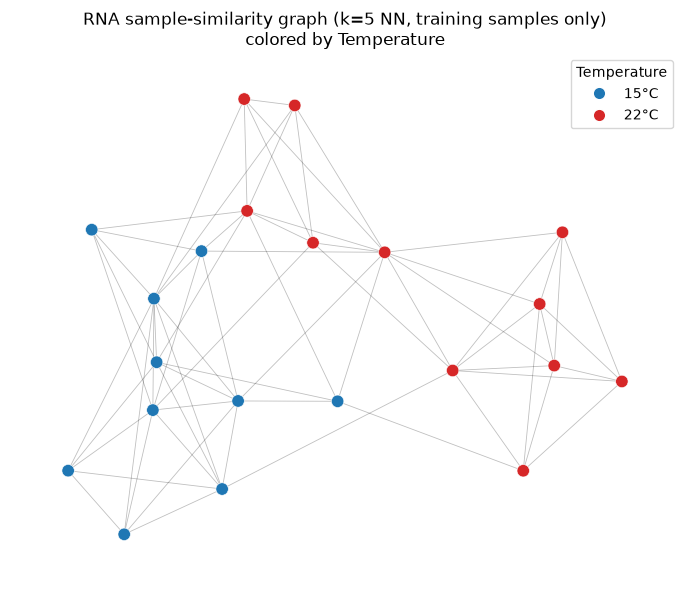

In [17]:
# ============================================================================
# Figure 1: Example modality-specific sample graph (RNA, training samples),
# colored by Temperature
# ============================================================================
import networkx as nx

rna_adj_binary = (train_adjacency["RNA"] > 0).astype(int)
np.fill_diagonal(rna_adj_binary, 0)
G = nx.from_numpy_array(rna_adj_binary)
pos = nx.spring_layout(G, seed=SEED, k=1.5 / np.sqrt(len(train_idx)))

node_colors = ["#1f77b4" if t == 0 else "#d62728" for t in y[train_idx]]

fig, ax = plt.subplots(figsize=(7, 6))
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=0.6)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=80, edgecolors="white", linewidths=0.4)
ax.set_title(f"RNA sample-similarity graph (k={K_NEIGHBORS} NN, training samples only)\ncolored by Temperature")
ax.axis("off")
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=9, label=lbl)
           for c, lbl in zip(["#1f77b4", "#d62728"], class_names)]
ax.legend(handles=handles, title="Temperature", loc="best")
plt.tight_layout()
plt.show()


### What the sample graphs represent

Each **node** is one biological sample; each **edge** connects two samples whose molecular
profiles (in that modality's PCA space) are among each other's `k` nearest neighbors. This
encodes the assumption that samples with similar molecular profiles in a given omics layer
are more likely to share the same biological state (here, temperature).

### Why each omics modality gets its own graph

RNA, protein, and metabolite profiles can have very different similarity structure - two
samples that look alike transcriptionally need not look alike metabolically. Building a
*separate* graph and GCN per modality lets each one learn its own modality-specific notion
of "similar samples" and its own modality-specific prediction, rather than forcing one
shared similarity structure onto all three data types.

### One GCN message-passing step

A single message-passing step replaces every sample's feature vector with the
(row-normalized) average of its own features and its graph neighbors' features:

```
H' = A_hat @ X          (A_hat: row-normalized adjacency with self-loops)
H' = ReLU(H' @ W)       (linear transform + non-linearity)
```

Stacking two such steps lets information propagate two hops across the sample graph, so a
sample's prediction is informed not just by its own PCA profile but by the profiles of
molecularly similar samples.


### Define the GCN and VCDN fusion modules

The GCN learns from each modality's sample graph. VCDN then combines the per-modality class probabilities, allowing the model to use cross-modality prediction patterns. Expect a confirmation that both modules were defined.

In [18]:
# ============================================================================
# STEP 5: Minimal pure-PyTorch GCN (per modality) + VCDN-style fusion
# ============================================================================
class SimpleGCN(nn.Module):
    '''Two-layer GCN: H' = ReLU(A_hat @ X @ W1), logits = A_hat @ H' @ W2.
    A_hat is the precomputed row-normalized adjacency (fixed, not learned).'''
    def __init__(self, in_dim, hidden_dim, n_classes):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, n_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, adj):
        h = adj @ x
        h = F.relu(self.fc1(h))
        h = self.dropout(h)
        h = adj @ h
        logits = self.fc2(h)
        return logits

class VCDN(nn.Module):
    '''Simplified View Correlation Discovery Network: takes the per-modality class
    probabilities, forms their outer-product "cross-modality correlation" tensor,
    flattens it, and passes it through a small MLP to produce the final prediction.'''
    def __init__(self, n_modalities, n_classes, hidden_dim=32):
        super().__init__()
        in_dim = n_classes ** n_modalities
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, n_classes)

    def forward(self, probs_list):
        # probs_list: list of (batch, n_classes) tensors, one per modality
        combined = probs_list[0]
        for p in probs_list[1:]:
            # outer product per sample -> (batch, prev_dim * n_classes)
            combined = torch.einsum("bi,bj->bij", combined, p).reshape(combined.shape[0], -1)
        h = F.relu(self.fc1(combined))
        return self.fc2(h)

print("[OK] Defined SimpleGCN (per-modality) and VCDN (fusion) modules")


[OK] Defined SimpleGCN (per-modality) and VCDN (fusion) modules


### What VCDN contributes

The simplified View Correlation Discovery Network (VCDN) takes each modality's predicted
class-probability vector and forms their outer product, producing a tensor whose entries
represent every possible *combination* of per-modality predictions (e.g. "RNA says 15°C
AND protein says 22°C"). Flattening this tensor and passing it through a small MLP lets
the fusion layer learn which cross-modality agreement/disagreement patterns are
informative, rather than simply averaging or concatenating the individual predictions.


### Train the three-modality MOGONET demonstration

This trains the RNA, proteomics, and metabolomics GCNs together with VCDN using training labels only, then evaluates the held-out samples. Expect periodic training loss and illustrative test accuracy and macro-F1.

In [19]:
# ============================================================================
# STEP 6: Train the MOGONET-style model using the TRAINING graph and TRAINING
# labels only. Test samples/labels never appear during training.
# ============================================================================
def train_mogonet(modalities, n_epochs=150, lr=0.01, hidden_dim=16, verbose=True):
    n_classes = len(class_names)
    gcns = {name: SimpleGCN(tensors_pca_train[name].shape[1], hidden_dim, n_classes) for name in modalities}
    vcdn = VCDN(n_modalities=len(modalities), n_classes=n_classes)

    params = list(vcdn.parameters())
    for gcn in gcns.values():
        params += list(gcn.parameters())
    optimizer = torch.optim.Adam(params, lr=lr, weight_decay=5e-4)

    history = []
    for epoch in range(1, n_epochs + 1):
        for gcn in gcns.values():
            gcn.train()
        vcdn.train()
        optimizer.zero_grad()

        probs_list, logits_list = [], []
        for name in modalities:
            logits = gcns[name](tensors_pca_train[name], adj_train_t[name])
            logits_list.append(logits)
            probs_list.append(F.softmax(logits, dim=1))

        fused_logits = vcdn(probs_list)

        # combined loss: per-modality supervision + fused supervision (TRAIN nodes only)
        loss = F.cross_entropy(fused_logits, y_train_t)
        for logits in logits_list:
            loss = loss + 0.5 * F.cross_entropy(logits, y_train_t)

        loss.backward()
        optimizer.step()
        history.append(loss.item())

        if verbose and (epoch == 1 or epoch % 30 == 0 or epoch == n_epochs):
            print(f"  Epoch {epoch:3d}/{n_epochs} | loss: {loss.item():.4f}")

    for gcn in gcns.values():
        gcn.eval()
    vcdn.eval()

    # Inference: run over the FULL graph (train+test), where test nodes connect only to
    # training neighbors. Only the resulting test-node predictions are used for evaluation.
    with torch.no_grad():
        probs_list = [F.softmax(gcns[name](tensors_pca_full[name], adj_full_t[name]), dim=1) for name in modalities]
        fused_logits = vcdn(probs_list)
        preds_full = fused_logits.argmax(dim=1).numpy()  # ordered as [train_idx, test_idx]

    n_train = len(train_idx)
    test_preds = preds_full[n_train:]
    return test_preds, history

print("Training full MOGONET-style model (RNA + Proteomics + Metabolomics)...")
mogonet_test_preds, mogonet_history = train_mogonet(["RNA", "Proteomics", "Metabolomics"])

y_test_true = y[test_idx]
mogonet_acc = accuracy_score(y_test_true, mogonet_test_preds)
mogonet_f1 = f1_score(y_test_true, mogonet_test_preds, average="macro")
print(f"\n[OK] MOGONET-style (3 modalities) | Test accuracy: {mogonet_acc:.3f} | Test macro-F1: {mogonet_f1:.3f}")


Training full MOGONET-style model (RNA + Proteomics + Metabolomics)...
  Epoch   1/150 | loss: 3.7547
  Epoch  30/150 | loss: 0.3695
  Epoch  60/150 | loss: 0.0366
  Epoch  90/150 | loss: 0.0122
  Epoch 120/150 | loss: 0.0198
  Epoch 150/150 | loss: 0.0081

[OK] MOGONET-style (3 modalities) | Test accuracy: 1.000 | Test macro-F1: 1.000


### View the MOGONET architecture

This diagram summarizes the three modality-specific graph/GCN paths and their VCDN fusion into temperature prediction. Expect a single architecture figure.

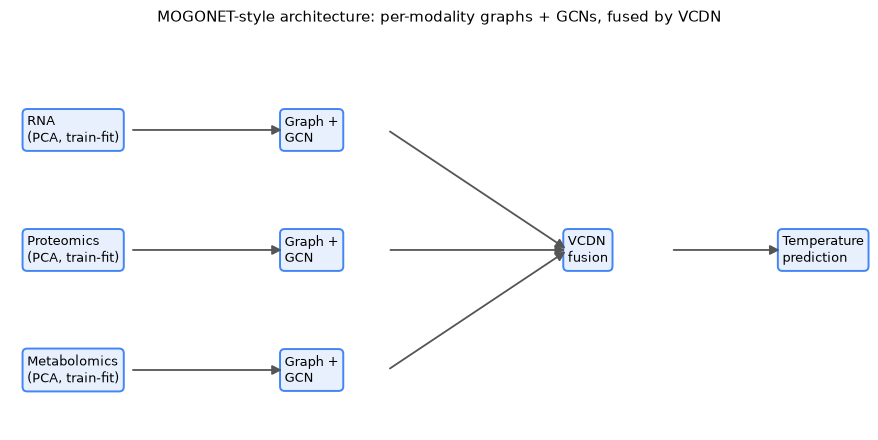

In [20]:
# ============================================================================
# Figure 2: Simple architecture diagram
# ============================================================================
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axis("off")

boxes = {
    "RNA":        (0.02, 0.75, "RNA\n(PCA, train-fit)"),
    "Prot":       (0.02, 0.45, "Proteomics\n(PCA, train-fit)"),
    "Met":        (0.02, 0.15, "Metabolomics\n(PCA, train-fit)"),
    "GCN_RNA":    (0.32, 0.75, "Graph +\nGCN"),
    "GCN_Prot":   (0.32, 0.45, "Graph +\nGCN"),
    "GCN_Met":    (0.32, 0.15, "Graph +\nGCN"),
    "VCDN":       (0.65, 0.45, "VCDN\nfusion"),
    "Pred":       (0.90, 0.45, "Temperature\nprediction"),
}
box_style = dict(boxstyle="round,pad=0.35", fc="#e8f0fe", ec="#4285f4", lw=1.4)
for key, (x, y0, label) in boxes.items():
    ax.text(x, y0, label, ha="left", va="center", fontsize=9.5, bbox=box_style, transform=ax.transAxes)

arrow_style = dict(arrowstyle="-|>", color="#555555", lw=1.3, mutation_scale=14)
pairs = [("RNA", "GCN_RNA"), ("Prot", "GCN_Prot"), ("Met", "GCN_Met"),
         ("GCN_RNA", "VCDN"), ("GCN_Prot", "VCDN"), ("GCN_Met", "VCDN"), ("VCDN", "Pred")]
for a, b in pairs:
    xa, ya, _ = boxes[a]
    xb, yb, _ = boxes[b]
    ax.annotate("", xy=(xb, yb), xytext=(xa + 0.12, ya), xycoords="axes fraction",
                textcoords="axes fraction", arrowprops=arrow_style)

ax.set_title("MOGONET-style architecture: per-modality graphs + GCNs, fused by VCDN", fontsize=11)
plt.tight_layout()
plt.show()


### Why Accuracy Alone Is Insufficient

All three methods below achieve perfect (or near-perfect) prediction on this small
dataset, so **accuracy does not demonstrate an advantage of MOGONET** here. Temperature is
strongly, linearly separable in this data, so any reasonable classifier - including a
simple RNA-only logistic regression - can solve it. The purpose of this comparison is
**not** to show that MOGONET is more accurate; it is to demonstrate *how* MOGONET arrives
at its prediction differently: by learning modality-specific sample relationships (via the
per-modality graphs and GCNs) and integrating complementary representations (via VCDN),
rather than treating all features as one flat, unordered input. The **modality-ablation
experiment** below is the more informative empirical demonstration, because it shows what
the model loses when a specific omics layer's graph-based representation is removed.


## Temperature prediction: baseline comparison

This evaluates RNA-only and concatenated-PCA logistic-regression baselines using the same train/test split and train-fit PCA features. It helps distinguish the graph-fusion workflow from simpler integration. Expect an accuracy and macro-F1 table for all methods.

In [21]:
# ============================================================================
# STEP 7: Simple baselines - RNA-only classifier, concatenated-PCA classifier.
# Both are fit on TRAINING samples only (using the train-fit PCA features) and
# evaluated on the held-out TEST samples.
# ============================================================================
def eval_logreg(X, name):
    clf = LogisticRegression(max_iter=1000, random_state=SEED)
    clf.fit(X[train_idx], y[train_idx])
    preds = clf.predict(X[test_idx])
    acc = accuracy_score(y[test_idx], preds)
    f1 = f1_score(y[test_idx], preds, average="macro")
    print(f"{name:28s} | Test accuracy: {acc:.3f} | Test macro-F1: {f1:.3f}")
    return acc, f1

print("Baseline comparisons:\n")
rna_only_acc, rna_only_f1 = eval_logreg(rna_pca.values, "RNA-only (PCA + LogReg)")
concat_acc, concat_f1 = eval_logreg(concat_pca.values, "Concatenated PCA + LogReg")
print(f"{'MOGONET-style (3 modalities)':28s} | Test accuracy: {mogonet_acc:.3f} | Test macro-F1: {mogonet_f1:.3f}")

results_summary = pd.DataFrame({
    "method": ["RNA-only", "Concatenated PCA", "MOGONET-style"],
    "accuracy": [rna_only_acc, concat_acc, mogonet_acc],
    "macro_f1": [rna_only_f1, concat_f1, mogonet_f1],
})
print(f"\n{results_summary.to_string(index=False)}")

print(
    "\n[CAVEAT] All methods achieve perfect prediction on this small dataset (n=30), so "
    "accuracy does not demonstrate an advantage of MOGONET. These numbers are ILLUSTRATIVE "
    "- they show that the MOGONET-style architecture runs end-to-end on real data with a "
    "leakage-free train/test protocol. They are NOT a rigorous performance benchmark and no "
    "method should be claimed superior on this basis. See the modality-ablation experiment "
    "below for a more informative demonstration of what each omics layer contributes."
)


Baseline comparisons:

RNA-only (PCA + LogReg)      | Test accuracy: 1.000 | Test macro-F1: 1.000
Concatenated PCA + LogReg    | Test accuracy: 1.000 | Test macro-F1: 1.000
MOGONET-style (3 modalities) | Test accuracy: 1.000 | Test macro-F1: 1.000

          method  accuracy  macro_f1
        RNA-only       1.0       1.0
Concatenated PCA       1.0       1.0
   MOGONET-style       1.0       1.0

[CAVEAT] All methods achieve perfect prediction on this small dataset (n=30), so accuracy does not demonstrate an advantage of MOGONET. These numbers are ILLUSTRATIVE - they show that the MOGONET-style architecture runs end-to-end on real data with a leakage-free train/test protocol. They are NOT a rigorous performance benchmark and no method should be claimed superior on this basis. See the modality-ablation experiment below for a more informative demonstration of what each omics layer contributes.


### Why this differs from simple PCA/concatenation

The baseline early-fusion approach (previous section, and the "Concatenated PCA" baseline
above) treats every PCA feature from every modality as an unordered, independent input to
one flat model - it has no notion of *sample relationships* and no mechanism to learn *how
the modalities agree or disagree* with each other. MOGONET instead (1) explicitly encodes
sample-to-sample relationships via the k-NN graphs, (2) lets each modality learn its own
representation/prediction with its own GCN, and (3) uses a learned, nonlinear
(outer-product-based) fusion step instead of a fixed linear concatenation.


### Plot the baseline comparison

This chart displays the held-out accuracy and macro-F1 values from the preceding cell. Expect two bars charts; interpret them as an illustration on a small real dataset, not a benchmark.

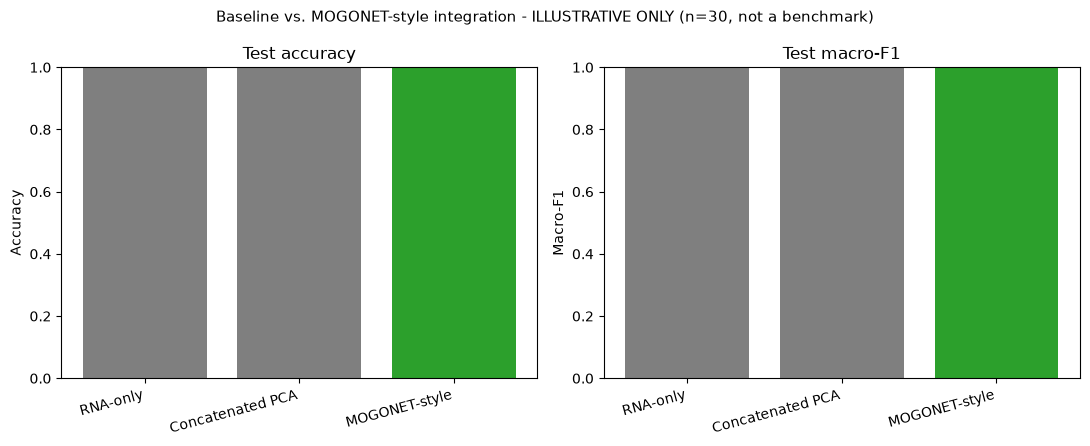

In [22]:
# ============================================================================
# Figure 3: Baseline vs MOGONET performance (illustrative, n=30)
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
x_pos = np.arange(len(results_summary))
colors = ["#7f7f7f", "#7f7f7f", "#2ca02c"]

axes[0].bar(x_pos, results_summary["accuracy"], color=colors)
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(results_summary["method"], rotation=15, ha="right")
axes[0].set_ylabel("Accuracy"); axes[0].set_ylim(0, 1); axes[0].set_title("Test accuracy")

axes[1].bar(x_pos, results_summary["macro_f1"], color=colors)
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(results_summary["method"], rotation=15, ha="right")
axes[1].set_ylabel("Macro-F1"); axes[1].set_ylim(0, 1); axes[1].set_title("Test macro-F1")

fig.suptitle("Baseline vs. MOGONET-style integration - ILLUSTRATIVE ONLY (n=30, not a benchmark)", fontsize=11)
plt.tight_layout()
plt.show()


### Modality Ablation: The Main Empirical Demonstration

Because accuracy alone does not distinguish MOGONET from the baselines here (see above),
the more informative experiment is to **remove one omics layer's graph+GCN at a time** and
observe how the fused (VCDN) prediction changes. This directly probes what each
modality-specific graph representation contributes to the shared prediction, rather than
just whether the final number is high.


## Modality ablation

This repeats the MOGONET-style evaluation while leaving out one modality at a time. It shows how the fused demonstration changes when RNA, proteomics, or metabolomics is unavailable. Expect one result row per omitted modality plus the full model.

In [23]:
# ============================================================================
# STEP 8: Modality-ablation experiment (remove each omics layer in turn).
# This is the main empirical demonstration of this section: it shows what
# changes in the fused prediction when RNA, proteomics, or metabolomics is
# excluded from the VCDN fusion, using the same leakage-free train/test
# protocol as the full model.
# ============================================================================
all_modalities = ["RNA", "Proteomics", "Metabolomics"]
ablation_results = []

print("Modality ablation (each row removes one modality's graph+GCN from VCDN fusion):\n")
for dropped in all_modalities:
    kept = [m for m in all_modalities if m != dropped]
    preds, _ = train_mogonet(kept, verbose=False)
    acc = accuracy_score(y_test_true, preds)
    f1 = f1_score(y_test_true, preds, average="macro")
    ablation_results.append({"removed_modality": dropped, "accuracy": acc, "macro_f1": f1})
    print(f"  Without {dropped:12s} -> accuracy: {acc:.3f} | macro-F1: {f1:.3f}")

ablation_results.append({"removed_modality": "None (full model)", "accuracy": mogonet_acc, "macro_f1": mogonet_f1})
ablation_df = pd.DataFrame(ablation_results)
print(f"\n{ablation_df.to_string(index=False)}")

print(
    "\n[HOW TO READ THIS] Each row uses only two of the three modality-specific graphs/GCNs "
    "in the VCDN fusion, instead of all three. A drop in accuracy/F1 relative to the full "
    "model row indicates that the removed modality's graph-based representation was "
    "contributing information the other two modalities did not already capture; an "
    "unchanged score indicates the remaining modalities were sufficient to separate "
    "Temperature on their own. With n=30 these differences are illustrative, not "
    "statistically robust."
)


Modality ablation (each row removes one modality's graph+GCN from VCDN fusion):

  Without RNA          -> accuracy: 1.000 | macro-F1: 1.000
  Without Proteomics   -> accuracy: 1.000 | macro-F1: 1.000
  Without Metabolomics -> accuracy: 1.000 | macro-F1: 1.000

 removed_modality  accuracy  macro_f1
              RNA       1.0       1.0
       Proteomics       1.0       1.0
     Metabolomics       1.0       1.0
None (full model)       1.0       1.0

[HOW TO READ THIS] Each row uses only two of the three modality-specific graphs/GCNs in the VCDN fusion, instead of all three. A drop in accuracy/F1 relative to the full model row indicates that the removed modality's graph-based representation was contributing information the other two modalities did not already capture; an unchanged score indicates the remaining modalities were sufficient to separate Temperature on their own. With n=30 these differences are illustrative, not statistically robust.


### Plot modality-ablation results

This visualizes the ablation accuracy and macro-F1 values. Expect a grouped bar chart that makes the illustrative change from each removed modality easy to compare.

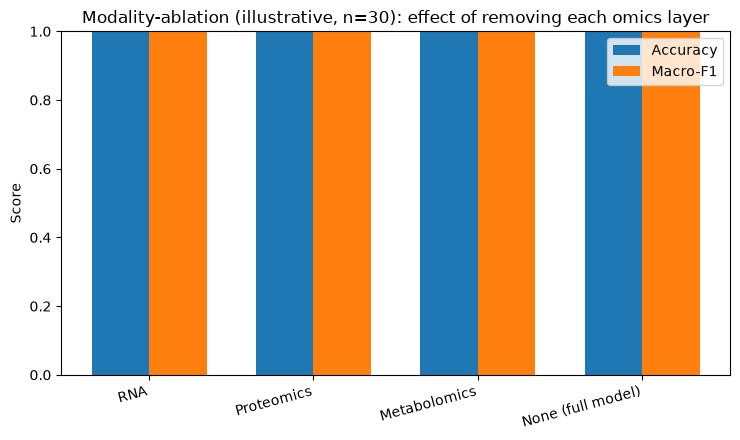

In [24]:
# ============================================================================
# Figure 4: Modality-ablation results (illustrative, n=30)
# ============================================================================
fig, ax = plt.subplots(figsize=(7.5, 4.5))
x_pos = np.arange(len(ablation_df))
width = 0.35
ax.bar(x_pos - width/2, ablation_df["accuracy"], width, label="Accuracy", color="#1f77b4")
ax.bar(x_pos + width/2, ablation_df["macro_f1"], width, label="Macro-F1", color="#ff7f0e")
ax.set_xticks(x_pos); ax.set_xticklabels(ablation_df["removed_modality"], rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Modality-ablation (illustrative, n=30): effect of removing each omics layer")
ax.legend()
plt.tight_layout()
plt.show()


## Take-home message

The frozen WallOmics data let you begin immediately with real matched samples and real temperature labels. PCA provides compact modality-specific views; sample-similarity graphs let GCNs use relationships among samples; VCDN fuses their complementary predictions. The split, PCA, and graph construction remain leakage-free throughout the demonstration.


In [25]:
# ============================================================================
# Final summary
# ============================================================================
print("MOGONET-style graph integration complete\n")
print(f"Samples: {n_samples} (train={len(train_idx)}, test={len(test_idx)})")
print(f"Prediction target: Temperature (15C vs 22C) [real WallomicsData experimental factor]")
print(f"K neighbors per graph: {K_NEIGHBORS}")
print(f"\n{results_summary.to_string(index=False)}")
print(
    "\nReminder: results above are ILLUSTRATIVE. They demonstrate that the architecture "
    "runs end-to-end on this small (n=30) real-data notebook using a leakage-free "
    "train/test protocol (PCA, scaling, and k-NN graphs fit on training data only). "
    "They are not a rigorous benchmark of biological performance."
)


MOGONET-style graph integration complete

Samples: 30 (train=21, test=9)
Prediction target: Temperature (15C vs 22C) [real WallomicsData experimental factor]
K neighbors per graph: 5

          method  accuracy  macro_f1
        RNA-only       1.0       1.0
Concatenated PCA       1.0       1.0
   MOGONET-style       1.0       1.0

Reminder: results above are ILLUSTRATIVE. They demonstrate that the architecture runs end-to-end on this small (n=30) real-data notebook using a leakage-free train/test protocol (PCA, scaling, and k-NN graphs fit on training data only). They are not a rigorous benchmark of biological performance.
